<h1 style="text-align:center;"><b>Proyecto 1</b></h1>
<h3 style="text-align:center;">Marcos Díaz (221102), Daniel Machic (22118), Maria Jose Ramírez (221051)</h3>

**GitHub**: https://github.com/mac2218/IA-Proyecto1.git

## Librerías

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/danielmachic/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/danielmachic/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Carga de Datos

In [ ]:
path = kagglehub.dataset_download("andrewmvd/cyberbullying-classification")
print("Ruta del dataset:", path)

file_path = os.path.join(path, "cyberbullying_tweets.csv")
df = pd.read_csv(file_path)

print(df.head())

Ruta del dataset: /Users/danielmachic/.cache/kagglehub/datasets/andrewmvd/cyberbullying-classification/versions/1
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


### Descripción del Dataset

El dataset utilizado contiene aproximadamente 47,000 tweets etiquetados en seis categorías:
- Age
- Ethnicity
- Gender
- Religion
- Other Cyberbullying
- Not Cyberbullying

El dataset presenta una distribución balanceada, con aproximadamente el mismo número de muestras por clase (~16.7%), lo que elimina la necesidad de aplicar técnicas de balanceo.

## Análisis Exploratorio


Distribución de clases:

                     Cantidad  Porcentaje (%)
cyberbullying_type                           
religion                 7998           16.77
age                      7992           16.76
gender                   7973           16.72
ethnicity                7961           16.69
not_cyberbullying        7945           16.66
other_cyberbullying      7823           16.40


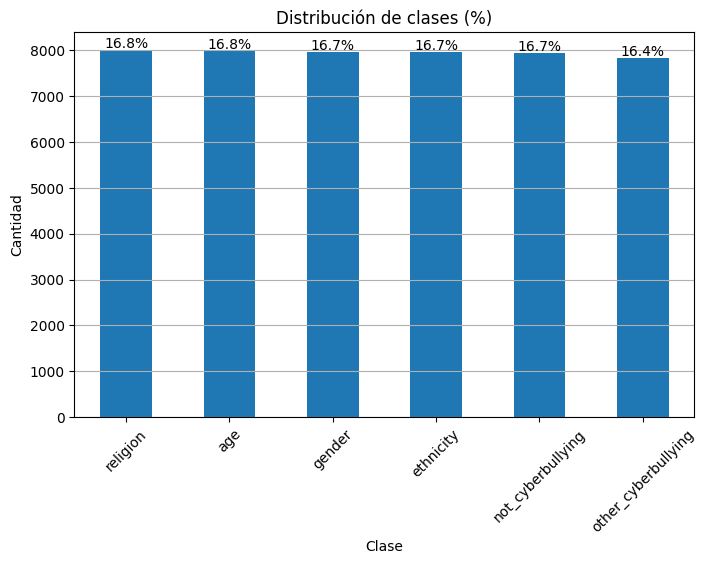

In [ ]:
# Conteo de clases
counts = df['cyberbullying_type'].value_counts()

# Porcentajes
percentages = df['cyberbullying_type'].value_counts(normalize=True) * 100

# Mostrar tabla combinada
resumen = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': percentages.round(2)
})

print("\nDistribución de clases:\n")
print(resumen)

# Gráfica con porcentajes en etiquetas
plt.figure(figsize=(8,5))
ax = counts.plot(kind='bar')

plt.title("Distribución de clases (%)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)

for i, v in enumerate(counts):
    plt.text(i, v + 50, f"{percentages.iloc[i]:.1f}%", ha='center')

plt.grid(axis='y')
plt.show()

La distribución de clases es altamente balanceada, con aproximadamente un 16.7% de observaciones por cada categoría. Esto indica que no existe un problema de desbalance de clases, por lo que no es necesario aplicar técnicas de oversampling o undersampling. Este equilibrio permite entrenar modelos de clasificación sin sesgo hacia una clase dominante y facilita una evaluación más confiable del desempeño.

## Pre-procesamiento de Texto
Se implementó un pipeline de procesamiento de lenguaje natural (NLP) con el objetivo de limpiar y normalizar los datos textuales.

Las etapas incluyeron:

- Conversión a minúsculas
- Eliminación de URLs, menciones y hashtags
- Eliminación de caracteres especiales y números
- Tokenización
- Eliminación de stopwords
- Lematización
- Reducción de caracteres repetidos

Ejemplo:

Texto original:
"@user You are so stupid!!!"

Texto procesado:
"stupid"

Este proceso permitió reducir el ruido en los datos y mejorar la calidad de las características utilizadas por los modelos.

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Eliminar URLs
    texto = re.sub(r"http\S+|www\S+", " ", texto)

    # 3. Eliminar menciones
    texto = re.sub(r"@\w+", " ", texto)

    # 4. Eliminar hashtags (# pero conservar palabra)
    texto = re.sub(r"#", "", texto)

    # 5. Reducir letras repetidas (AQUÍ VA TU LÍNEA)
    texto = re.sub(r"(.)\1+", r"\1\1", texto)

    # 6. Eliminar números
    texto = re.sub(r"\d+", " ", texto)

    # 7. Eliminar caracteres especiales
    texto = re.sub(r"[^a-z\s]", " ", texto)

    # 8. Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    # 9. Tokenización
    palabras = texto.split()

    # 10. Stopwords + lematización
    palabras = [
        lemmatizer.lemmatize(p)
        for p in palabras
        if p not in stop_words and len(p) > 2
    ]

    return " ".join(palabras)


df['clean_text'] = df['tweet_text'].apply(limpiar_texto)

for i in range(5):
    print("ORIGINAL:", df['tweet_text'][i])
    print("LIMPIO:  ", df['clean_text'][i])
    print()

ORIGINAL: In other words #katandandre, your food was crapilicious! #mkr
LIMPIO:   word katandandre food crapilicious mkr

ORIGINAL: Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc
LIMPIO:   aussietv white mkr theblock imacelebrityau today sunrise studio neighbour wonderlandten etc

ORIGINAL: @XochitlSuckkks a classy whore? Or more red velvet cupcakes?
LIMPIO:   classy whore red velvet cupcake

ORIGINAL: @Jason_Gio meh. :P  thanks for the heads up, but not too concerned about another angry dude on twitter.
LIMPIO:   meh thanks head concerned another angry dude twitter

ORIGINAL: @RudhoeEnglish This is an ISIS account pretending to be a Kurdish account.  Like Islam, it is all lies.
LIMPIO:   isi account pretending kurdish account like islam lie



Se eliminaron palabras irrelevantes (stopwords), caracteres especiales y ruido del texto, conservando únicamente términos con valor semántico para la clasificación.